## Tai Dinh, Week 4, Baseline Model

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn import linear_model as lm
from sklearn.metrics import r2_score

In [42]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Load in CSV's, Remove Outliers, and Select Features

In [43]:
test_df = pd.read_csv('/content/test_df.csv')
train_df = pd.read_csv('/content/train_df.csv')

/tmp/ipykernel_2490/3141949115.py:1: DtypeWarning: Columns (66) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df = pd.read_csv('/content/test_df.csv')
/tmp/ipykernel_2490/3141949115.py:2: DtypeWarning: Columns (66,107,139,140) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv('/content/train_df.csv')


In [44]:
train_df = train_df[(train_df["ClosePrice"] <= 600000000) & (train_df["ClosePrice"] > 0)]

In [45]:
cols = ["LivingArea", "YearBuilt", "ParkingTotal", "BathroomsTotalInteger", "GarageSpaces", "AssociationFee", "AttachedGarageYN", "PoolPrivateYN", "ViewYN"]
X_train = train_df[cols]
Y_train = train_df["ClosePrice"]
X_test = test_df[cols]
Y_test = test_df["ClosePrice"]

# Train Linear Regression Model

In [46]:
model = lm.LinearRegression()
model.fit(X_train, Y_train)

preds = model.predict(X_test)

# Find $R^2$ and Plot


0.30700924466904467


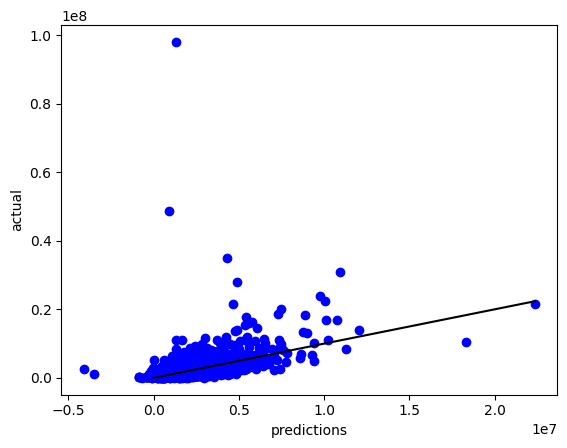

In [47]:
print(r2_score(Y_test, preds))

plt.scatter(preds, Y_test, color='blue')
plt.plot([0, max(preds)], [0, max(preds)], color = 'black')
plt.xlabel('predictions')
plt.ylabel('actual')
plt.show()


The baseline model does not do very well and has a long way to go.